<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Si_and_SiGe_at_Low_Temperature_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

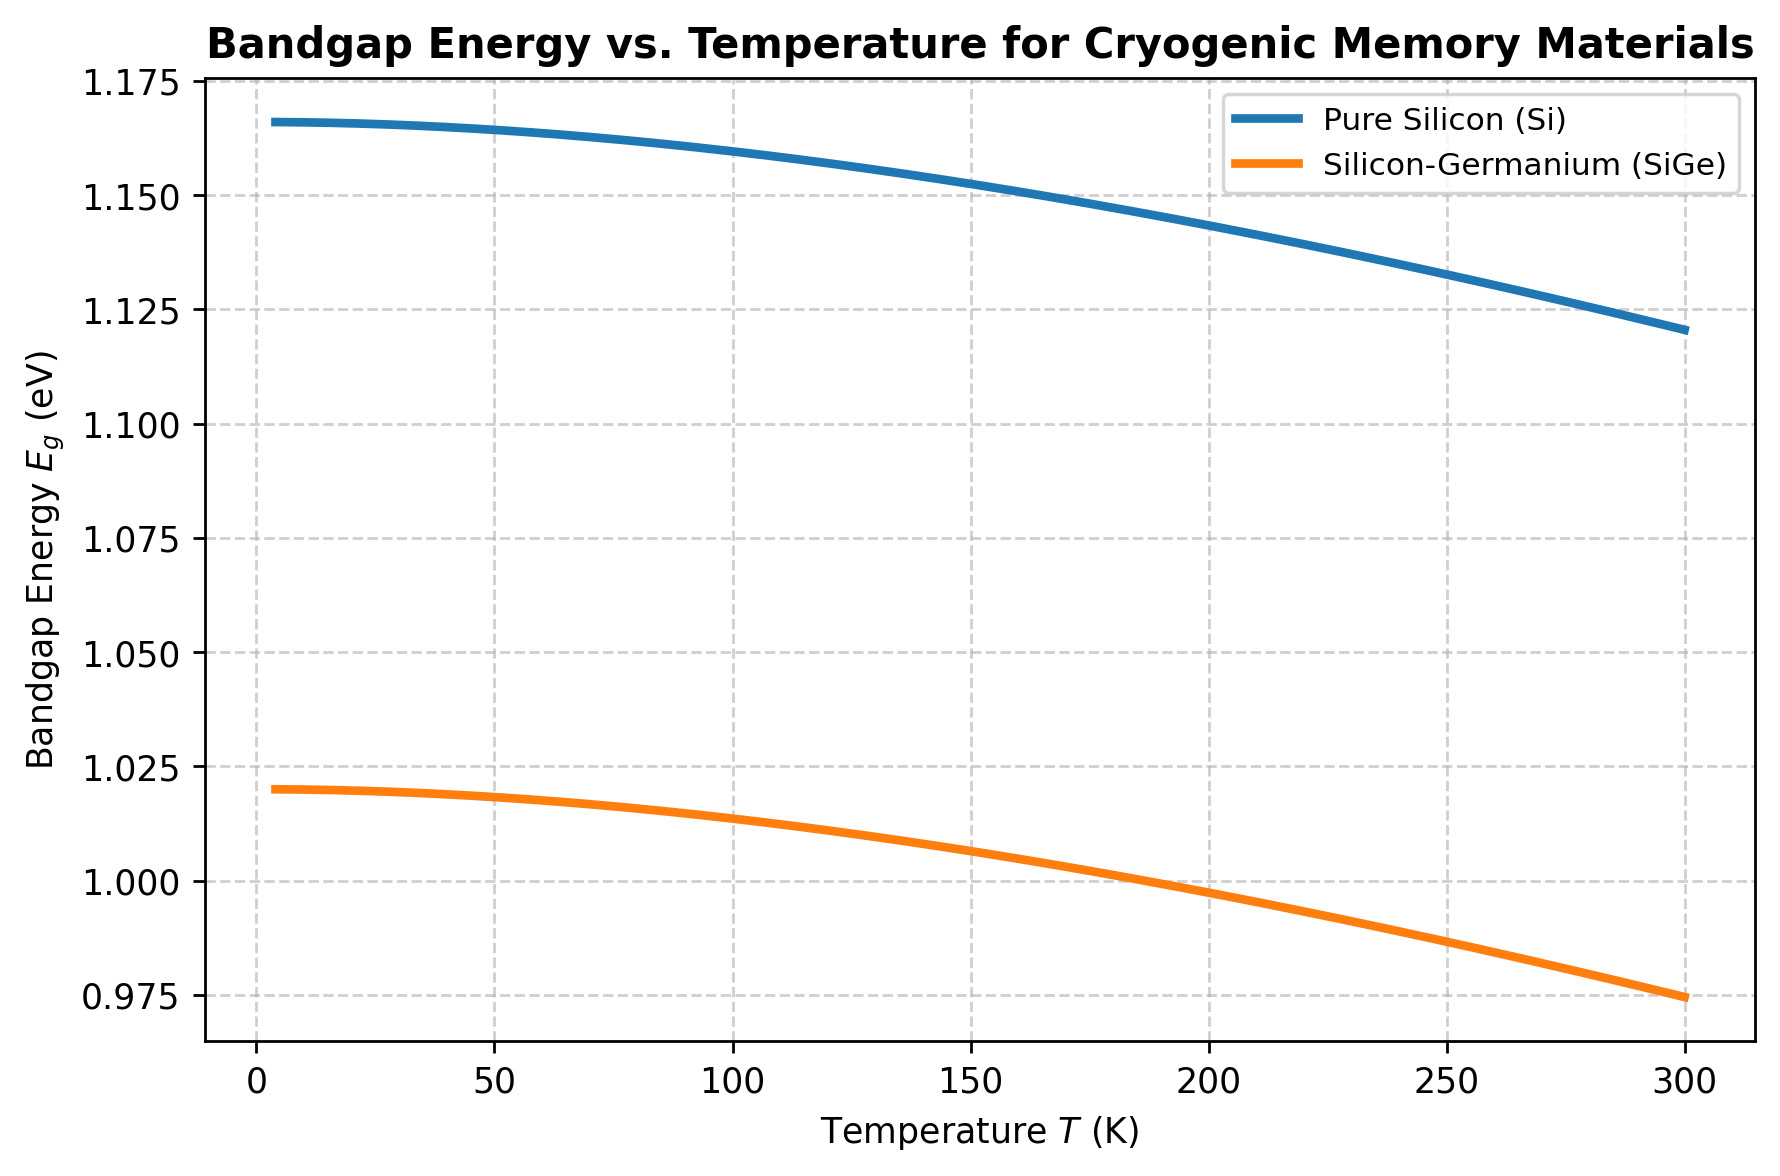

In [1]:
"""
Modeling Temperature Dependence of Si and SiGe Bandgaps.
This script computes and plots the bandgap energy for pure Silicon
and a representative Silicon-Germanium alloy across a continuous temperature range.
"""

# ==========================================
# CONTROL KNOBS
# ==========================================
T_MIN = 4.0          # Minimum temperature (Kelvin)
T_MAX = 300.0        # Maximum temperature (Kelvin)
N_POINTS = 200       # Number of temperature simulation points
EG_0_SI = 1.166      # Bandgap of pure Silicon at 0K (eV)
EG_0_SIGE = 1.02     # Approximate bandgap of SiGe at 0K (eV)
ALPHA_SI = 4.73e-4   # Varshni alpha coefficient for Silicon (eV/K)
BETA_SI = 636.0      # Varshni beta coefficient for Silicon (K)
# ==========================================

import subprocess
import sys

# Ensure required libraries are installed via pip
try:
    import numpy as np
    import matplotlib.pyplot as plt
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy", "matplotlib"])
    import numpy as np
    import matplotlib.pyplot as plt

# Apply standard rendering preferences for Colab
plt.rcParams['figure.dpi'] = 250
plt.rcParams['savefig.dpi'] = 250

def calculate_varshni_bandgap(temperature_array: np.ndarray, eg_0: float, alpha: float, beta: float) -> np.ndarray:
    """
    Calculates the bandgap energy using the Varshni empirical equation.

    Args:
        temperature_array (np.ndarray): Array of temperature values in Kelvin.
        eg_0 (float): Bandgap energy at 0 Kelvin in eV.
        alpha (float): Material-specific alpha parameter in eV/K.
        beta (float): Material-specific beta parameter in Kelvin.

    Returns:
        np.ndarray: Calculated bandgap energies in eV.
    """
    return eg_0 - (alpha * temperature_array**2) / (temperature_array + beta)

def main():
    """Executes the bandgap simulation and renders the plot directly to the interface."""
    temperatures = np.linspace(T_MIN, T_MAX, N_POINTS)

    # Calculate bandgaps across the temperature array
    bandgap_si = calculate_varshni_bandgap(temperatures, EG_0_SI, ALPHA_SI, BETA_SI)
    bandgap_sige = calculate_varshni_bandgap(temperatures, EG_0_SIGE, ALPHA_SI, BETA_SI)

    # Render the plot directly
    plt.figure(figsize=(8, 5))
    plt.plot(temperatures, bandgap_si, label='Pure Silicon (Si)', linewidth=2.5, color='#1f77b4')
    plt.plot(temperatures, bandgap_sige, label='Silicon-Germanium (SiGe)', linewidth=2.5, color='#ff7f0e')

    plt.title('Bandgap Energy vs. Temperature for Cryogenic Memory Materials', fontsize=12, fontweight='bold')
    plt.xlabel('Temperature $T$ (K)', fontsize=10)
    plt.ylabel('Bandgap Energy $E_g$ (eV)', fontsize=10)
    plt.legend(loc='best', fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Render explicitly without saving to disk
    plt.show()

if __name__ == "__main__":
    main()